In [ ]:
# https://codeforces.com/problemset/problem/540/D
# Problem Link👆

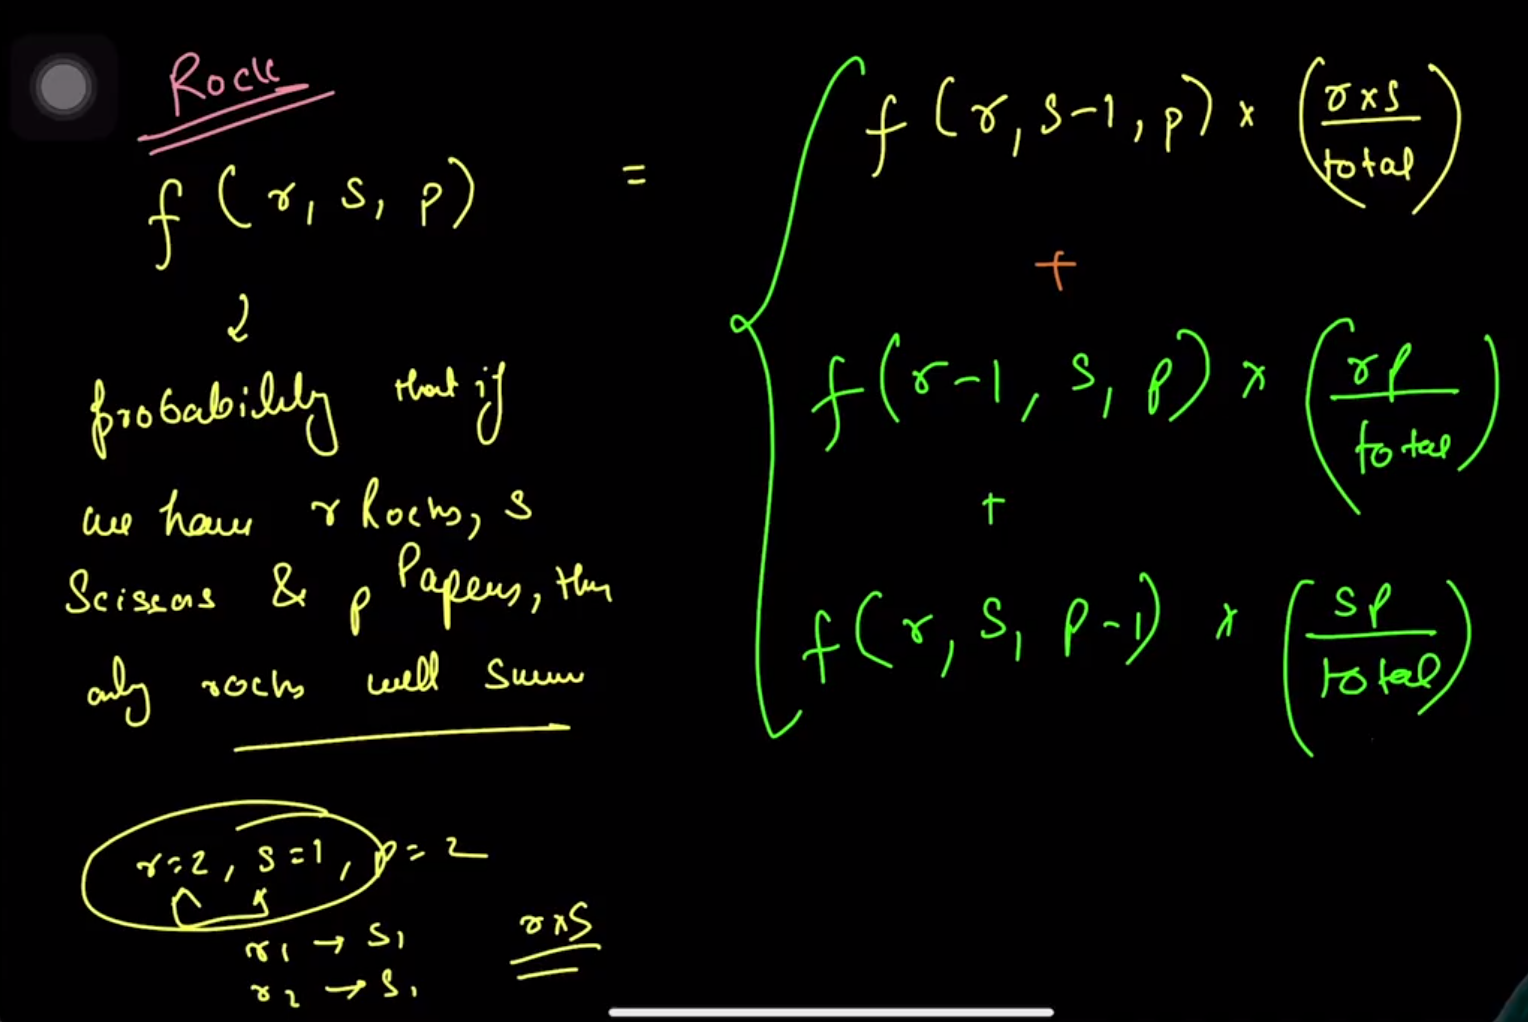

In [3]:
# Base Case

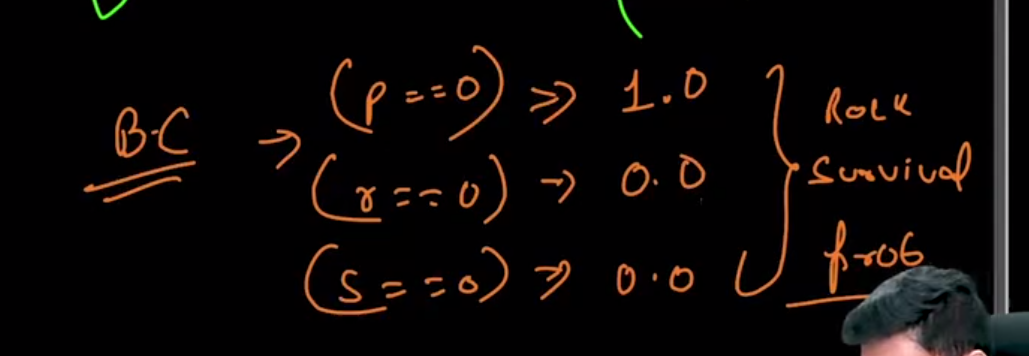

In [ ]:
# For scissor👇

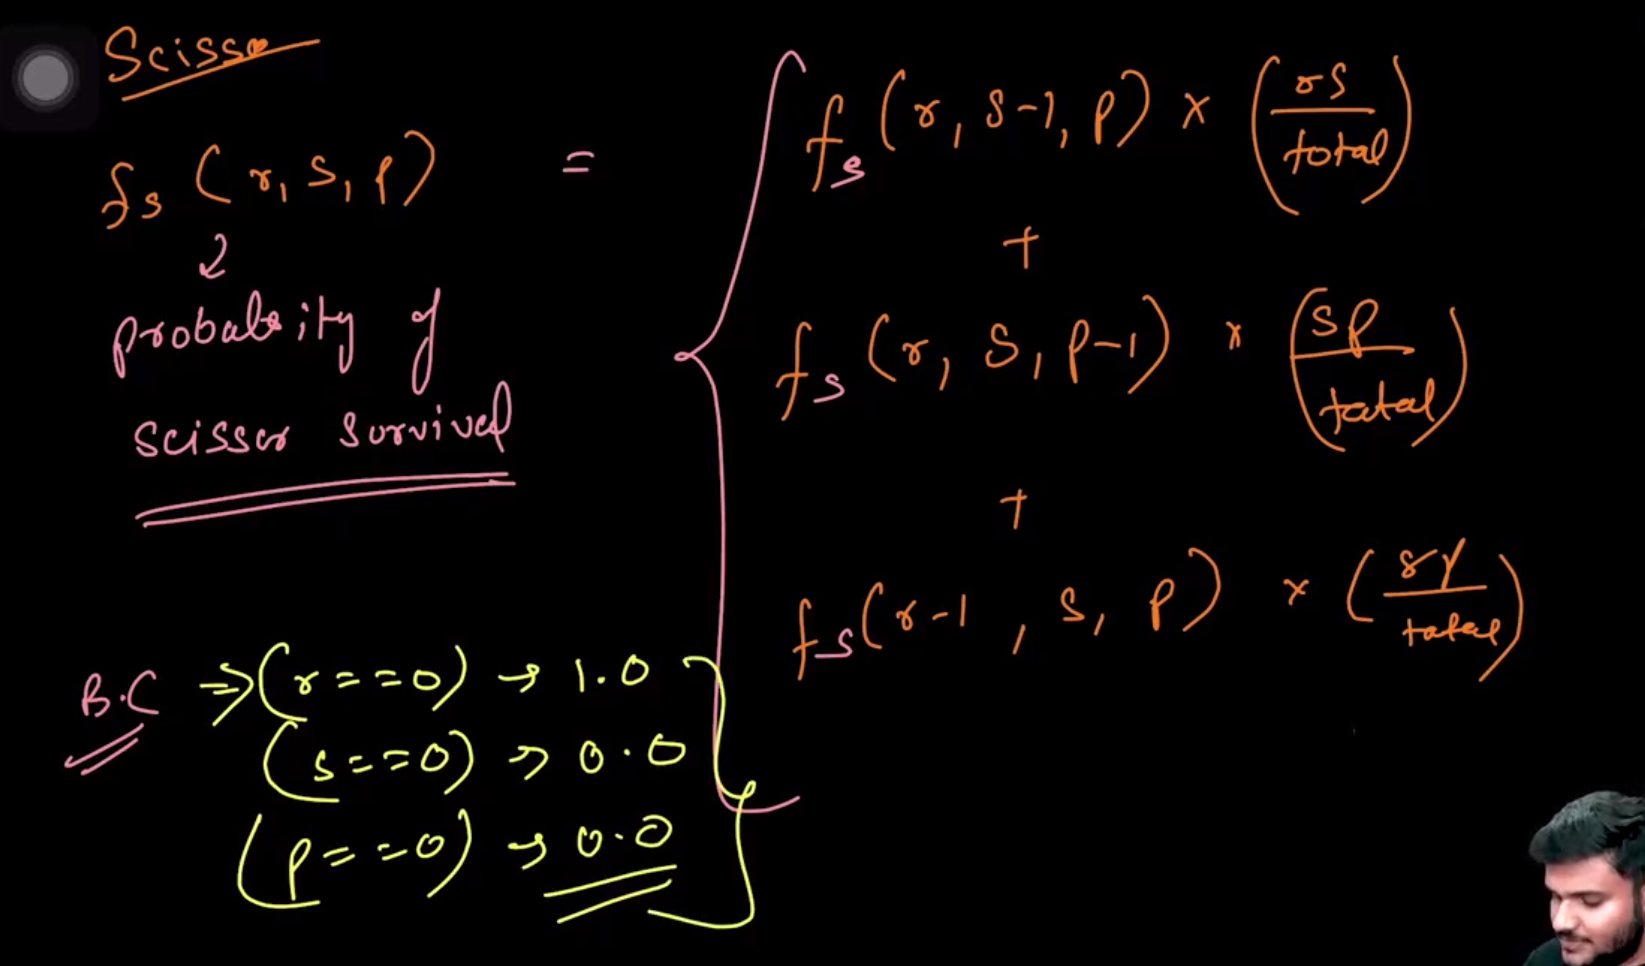

In [ ]:
# for paper👇

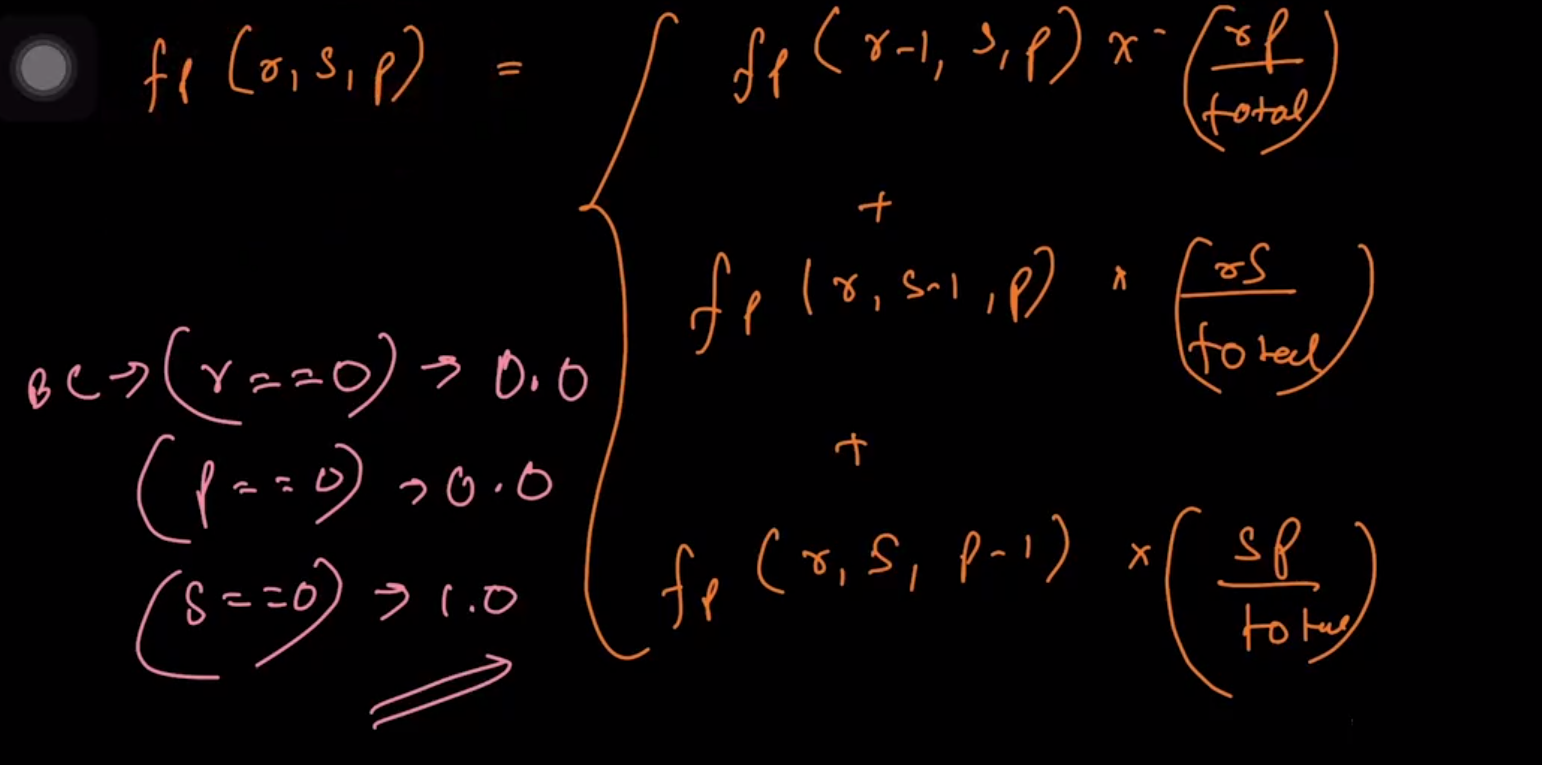

In [4]:
# Only base condition changes in all the functions

In [6]:
class Solution:

    def __init__(self):
        # dp[r][s][p]
        self.dp = [
            [
                [-1.0 for _ in range(101)]
                for _ in range(101)
            ]
            for _ in range(101)
        ]

    # Probability that Rock survives
    def fr(self, r, s, p):

        # Rock or Scissors is already finished
        if r == 0 or s == 0:
            return 0.0

        # No Paper left -> Rock survives
        if p == 0:
            return 1.0

        # Already calculated
        if self.dp[r][s][p] > -0.9:
            return self.dp[r][s][p]

        total = r * s + s * p + p * r

        result = 0.0

        # Rock kills Scissors
        result += self.fr(r - 1, s, p) * ((s * p) / total)

        # Scissors kills Rock
        result += self.fr(r, s - 1, p) * ((r * s) / total)

        # Paper kills Scissors
        result += self.fr(r, s, p - 1) * ((r * p) / total)

        self.dp[r][s][p] = result

        return result

    # Probability that Scissors survives
    def fs(self, r, s, p):

        # Scissors or Paper is already finished
        if s == 0 or p == 0:
            return 0.0

        # No Rock left -> Scissors survives
        if r == 0:
            return 1.0

        # Already calculated
        if self.dp[r][s][p] > -0.9:
            return self.dp[r][s][p]

        total = r * s + s * p + p * r

        result = 0.0

        # Rock kills Scissors
        result += self.fs(r - 1, s, p) * ((s * p) / total)

        # Scissors kills Rock
        result += self.fs(r, s - 1, p) * ((r * s) / total)

        # Paper kills Scissors
        result += self.fs(r, s, p - 1) * ((s * p) / total)

        self.dp[r][s][p] = result

        return result

    # Probability that Paper survives
    def fp(self, r, s, p):

        # Paper or Rock is already finished
        if p == 0 or r == 0:
            return 0.0

        # No Scissors left -> Paper survives
        if s == 0:
            return 1.0

        # Already calculated
        if self.dp[r][s][p] > -0.9:
            return self.dp[r][s][p]

        total = r * s + s * p + p * r

        result = 0.0

        # Rock kills Scissors
        result += self.fp(r - 1, s, p) * ((r * p) / total)

        # Scissors kills Rock
        result += self.fp(r, s - 1, p) * ((r * s) / total)

        # Paper kills Scissors
        result += self.fp(r, s, p - 1) * ((s * p) / total)

        self.dp[r][s][p] = result

        return result


# Driver code

r, s, p = map(int, input().split())

obj = Solution()

rock = obj.fr(r, s, p)

# Reset DP before calculating the next probability
obj.dp = [
    [
        [-1.0 for _ in range(101)]
        for _ in range(101)
    ]
    for _ in range(101)
]

scissors = obj.fs(r, s, p)

# Reset DP again
obj.dp = [
    [
        [-1.0 for _ in range(101)]
        for _ in range(101)
    ]
    for _ in range(101)
]

paper = obj.fp(r, s, p)

print(f"{rock:.12f} {scissors:.12f} {paper:.12f}")

0.316666666667 0.405555555556 0.333333333333


In [ ]:
class Solution:

    def __init__(self):
        self.dp_r = [
            [
                [-1.0 for _ in range(101)]
                for _ in range(101)
            ]
            for _ in range(101)
        ]

        self.dp_s = [
            [
                [-1.0 for _ in range(101)]
                for _ in range(101)
            ]
            for _ in range(101)
        ]

        self.dp_p = [
            [
                [-1.0 for _ in range(101)]
                for _ in range(101)
            ]
            for _ in range(101)
        ]

    def fr(self, r, s, p):

        if r == 0 or s == 0:
            return 0.0

        if p == 0:
            return 1.0

        if self.dp_r[r][s][p] > -0.9:
            return self.dp_r[r][s][p]

        total = r * s + s * p + p * r

        result = 0.0

        result += self.fr(r - 1, s, p) * (s * p / total)
        result += self.fr(r, s - 1, p) * (r * s / total)
        result += self.fr(r, s, p - 1) * (r * p / total)

        self.dp_r[r][s][p] = result

        return result

    def fs(self, r, s, p):

        if s == 0 or p == 0:
            return 0.0

        if r == 0:
            return 1.0

        if self.dp_s[r][s][p] > -0.9:
            return self.dp_s[r][s][p]

        total = r * s + s * p + p * r

        result = 0.0

        result += self.fs(r - 1, s, p) * (s * p / total)
        result += self.fs(r, s - 1, p) * (r * s / total)
        result += self.fs(r, s, p - 1) * (s * p / total)

        self.dp_s[r][s][p] = result

        return result

    def fp(self, r, s, p):

        if p == 0 or r == 0:
            return 0.0

        if s == 0:
            return 1.0

        if self.dp_p[r][s][p] > -0.9:
            return self.dp_p[r][s][p]

        total = r * s + s * p + p * r

        result = 0.0

        result += self.fp(r - 1, s, p) * (r * p / total)
        result += self.fp(r, s - 1, p) * (r * s / total)
        result += self.fp(r, s, p - 1) * (s * p / total)

        self.dp_p[r][s][p] = result

        return result


# Driver code

r, s, p = map(int, input().split())

obj = Solution()

rock = obj.fr(r, s, p)
scissors = obj.fs(r, s, p)
paper = obj.fp(r, s, p)

print(f"{rock:.12f} {scissors:.12f} {paper:.12f}")